In [1]:
# API vs MCP, Framework Selection, and Build vs Buy

In [2]:
# Objectives

# By the end of this notebook you will be able to:
# - Compare REST and MCP integration using live external services
# - Understand why schema standardisation matters at enterprise scale
# - Select between LangChain, LangGraph, and Python-only based on TCO
# - Apply a structured Build vs Buy rubric to any AI tooling decision
# - Produce an ARB-ready framework selection matrix for the Walmart Retail Assistant

# Deliverable: framework_selection_matrix.txt

In [3]:
# https://serpapi.com/manage-api-key

# https://home.openweathermap.org/api_keys

# https://newsapi.ai/login

# https://www.tavily.com/

In [4]:
# Load the libraries and keys needed for the full notebook.
# This cell also defines the store we will use in every example.
import os
import json
import time
import requests
from typing import TypedDict
from dotenv import load_dotenv
from openai import OpenAI

load_dotenv(override=True)

OPENAI_KEY  = os.getenv('OPENAI_API_KEY')
WEATHER_KEY = os.getenv('OPENWEATHERMAP_API_KEY')
TAVILY_KEY  = os.getenv('TAVILY_API_KEY')

client = OpenAI(api_key=OPENAI_KEY)

# Check whether all required API keys are present before we continue.
missing = [k for k, v in {
    'OPENAI_API_KEY':         OPENAI_KEY,
    'OPENWEATHERMAP_API_KEY': WEATHER_KEY,
    'TAVILY_API_KEY':         TAVILY_KEY,
}.items() if not v]

if missing:
    print(f'WARNING: Missing API keys: {missing}')
    print('Add them to your .env file before running this notebook.')
else:
    print('All required API keys loaded.')

# Fixed store context keeps every comparison in the notebook consistent.
STORE_ID   = 'WMT-2847'
STORE_CITY = 'Bengaluru'
print(f'Store context: {STORE_ID} | {STORE_CITY}, India')

All required API keys loaded.
Store context: WMT-2847 | Bengaluru, India


In [5]:
# Q: Based on today’s weather and current market demand, which product categories should I prioritise stocking?
# Answers three decisions:
# 1. REST API or MCP?
# 2. Which framework should be used? - Python-only, LangChain, LangGraph
# 3. Should Walmart build or buy each component?

# Overall business objective:
# Design a scalable Walmart Retail Assistant that uses live data, has reusable tools, supports complex workflows, controls cost and latency, and is suitable for Architecture Review Board approval.

# Deliverable: framework_selection_matrix.txt

## The Decision Landscape

Every production AI system at Walmart scale requires three interlocking decisions made before any code is written:

1. **Protocol selection:** How should your AI agent communicate with external systems? REST API or Model Context Protocol (MCP)?
2. **Framework selection:** What orchestration layer do you build on? LangChain, LangGraph, or Python-only?
3. **Build vs Buy:** For each component, is it cheaper to build it or to buy a vendor solution?

Each decision compounds. A wrong protocol choice forces a framework rewrite downstream.

**The running scenario throughout this notebook:**

> *You are the AI engineer for the Walmart India Retail Assistant deployed at 4,700 stores with 50,000+ queries per day. The store manager at WMT-2847 in Bengaluru asks: "Based on today's actual conditions, what should we prioritise stocking today?"*

Every tool call in this notebook returns **live data** from real external APIs. The recommendation changes based on real weather and real market signals retrieved at runtime.

In [9]:
# Core API Functions

def fetch_weather(city: str, country_code: str = 'IN') -> dict:
    # Call the live OpenWeatherMap API for current weather.
    url    = 'https://api.openweathermap.org/data/2.5/weather'
    params = {'q': f'{city},{country_code}', 'appid': WEATHER_KEY, 'units': 'metric'}
    resp   = requests.get(url, params=params, timeout=10)
    resp.raise_for_status()
    d = resp.json()
    # For debugging purpose, lets print the API response
    # print("=="*35)
    # print(d)
    # print("=="*35)
    return {
        'city':           d['name'],
        'country':        d['sys']['country'],
        'temperature_c':  round(d['main']['temp'], 1),
        'feels_like_c':   round(d['main']['feels_like'], 1),
        'humidity_pct':   d['main']['humidity'],
        'condition':      d['weather'][0]['description'],
        'condition_main': d['weather'][0]['main'],
        'wind_speed_ms':  d['wind']['speed'],
        'pressure_hpa':   d['main']['pressure'],
    }

def fetch_demand_trends(query: str, max_results: int = 3) -> dict:
    # Call the live Tavily API for current market demand signals.
    resp = requests.post(
        'https://api.tavily.com/search',
        json={
            'api_key':        TAVILY_KEY,
            'query':          query,
            'max_results':    max_results,
            'search_depth':   'basic',
            'include_answer': True,
        },
        timeout=15,
    )
    resp.raise_for_status()
    data = resp.json()
    return {
        'answer':  data.get('answer', ''),
        'results': [
            {'title': r['title'], 'content': r['content'][:350]}
            for r in data.get('results', [])
        ],
    }

In [10]:
STORE_CITY

'Bengaluru'

In [8]:
# Quick live check so we know both external services are working.
print('Verifying live API connections...')
print()

live_weather = fetch_weather(STORE_CITY) # fetch_weather("Bengaluru")
print(f'OpenWeatherMap -- {live_weather["city"]}, {live_weather["country"]}:')
print(f'  Temperature : {live_weather["temperature_c"]} C  (feels like {live_weather["feels_like_c"]} C)')
print(f'  Condition   : {live_weather["condition"]}')
print(f'  Humidity    : {live_weather["humidity_pct"]}%   Wind: {live_weather["wind_speed_ms"]} m/s')

print()
live_demand = fetch_demand_trends(f'retail grocery product demand {STORE_CITY} India')
print(f'Tavily Search -- query returned {len(live_demand["results"])} results:')
if live_demand['answer']:
    print(f'  Synthesised: {live_demand["answer"][:220]}...')
for r in live_demand['results'][:2]:
    print(f'  - {r["title"][:80]}')

Verifying live API connections...

{'coord': {'lon': 77.6033, 'lat': 12.9762}, 'weather': [{'id': 804, 'main': 'Clouds', 'description': 'overcast clouds', 'icon': '04d'}], 'base': 'stations', 'main': {'temp': 23.84, 'feels_like': 24.29, 'temp_min': 23.61, 'temp_max': 24.06, 'pressure': 1013, 'humidity': 77, 'sea_level': 1013, 'grnd_level': 915}, 'visibility': 10000, 'wind': {'speed': 6.06, 'deg': 258, 'gust': 8.85}, 'clouds': {'all': 100}, 'dt': 1784692904, 'sys': {'type': 2, 'id': 2094842, 'country': 'IN', 'sunrise': 1784680356, 'sunset': 1784726345}, 'timezone': 19800, 'id': 1277333, 'name': 'Bengaluru', 'cod': 200}
OpenWeatherMap -- Bengaluru, IN:
  Temperature : 23.8 C  (feels like 24.3 C)
  Condition   : overcast clouds
  Humidity    : 77%   Wind: 6.06 m/s

Tavily Search -- query returned 3 results:
  Synthesised: In Bengaluru, India, demand for fruits like mangoes and watermelons, and beverages such as coconut water is high. D-Mart is popular for groceries. The city's growing mar

In [15]:
# REST API Integration
# Strengths: Mature ecosystem, no new dependencies, works with any HTTP service.
# Weakness: Tool schema lives in the developer's prompt. Schema drift and multi-agent reuse require copy-pasting descriptions across every agent that needs the tool.

# The two tools below call real external APIs on every invocation:
# a. get_store_weather -- live call to OpenWeatherMap
# b. search_demand_trends -- live call to Tavily Search

# This cell shows the REST approach.
# The developer writes the tool schema by hand and the model uses it.
# REST tool schema -- developer writes this by hand for each agent that needs it
REST_TOOLS = [
    {
        'type': 'function',
        'function': {
            'name': 'get_store_weather',
            'description': (
                'Get real-time weather at a Walmart India store location. '
                'Use this to identify weather-driven demand: '
                'rain drives umbrella/raincoat/waterproof footwear sales, '
                'heat drives cold beverages/ice cream/sunscreen sales, '
                'cold drives hot beverages/heaters/blanket sales.'
            ),
            'parameters': {
                'type': 'object',
                'properties': {
                    'city':         {'type': 'string', 'description': 'City where the Walmart store is located'},
                    'country_code': {'type': 'string', 'description': 'ISO country code (default IN for India)'},
                },
                'required': ['city'],
            },
        },
    },
    {
        'type': 'function',
        'function': {
            'name': 'search_demand_trends',
            'description': (
                'Search for real-time retail product demand trends and market signals using Tavily. '
                'Use this to identify high-demand product categories based on current market conditions.'
            ),
            'parameters': {
                'type': 'object',
                'properties': {
                    'query':       {'type': 'string', 'description': 'Search query for demand or market signals'},
                    'max_results': {'type': 'integer', 'description': 'Number of results to return (1-5)'},
                },
                'required': ['query'],
            },
        },
    },
]

# This function acts like a dispatcher or router.
def execute_rest_tool(name: str, args: dict) -> str:
    # Route each REST tool call to the matching Python function.
    if name == 'get_store_weather':
        result = fetch_weather(args['city'], args.get('country_code', 'IN'))
    elif name == 'search_demand_trends':
        result = fetch_demand_trends(args['query'], args.get('max_results', 3))
    else:
        result = {'error': f'Unknown tool: {name}'}
    return json.dumps(result)

# Creating the REST Agent
def walmart_rest_agent(query: str) -> dict: # query=""What products should we increase at the Bengaluru store today?""
    # Run a full REST-style agent loop with live tool calls.
    start    = time.time()
    messages = [
        {
            'role': 'system',
            'content': (
                f'You are an AI assistant for Walmart India store {STORE_ID} in {STORE_CITY}. '
                'Use available tools to retrieve live data before making recommendations. '
                'Base your answer entirely on the real data returned by the tools.'
            ),
        },
        {'role': 'user', 'content': query},
    ]

    tools_called = []
    total_in = total_out = 0

    # Keep calling the model until it stops asking for tools.
    for _ in range(6):
        resp = client.chat.completions.create(
            model='gpt-4o-mini', messages=messages, tools=REST_TOOLS,
            tool_choice='auto', temperature=0, max_tokens=500,
        )
        total_in  += resp.usage.prompt_tokens
        total_out += resp.usage.completion_tokens
        msg = resp.choices[0].message

        if not msg.tool_calls:
            final_answer = msg.content.strip()
            break

        messages.append(msg)
        for tc in msg.tool_calls:
            args   = json.loads(tc.function.arguments)
            result = execute_rest_tool(tc.function.name, args)
            tools_called.append({'tool': tc.function.name, 'args': args})
            messages.append({'role': 'tool', 'tool_call_id': tc.id, 'content': result})

    latency = time.time() - start
    cost    = (total_in * 0.15 + total_out * 0.60) / 1_000_000
    return {
        'answer':       final_answer,
        'tools_called': tools_called,
        'latency_sec':  round(latency, 2),
        'cost_usd':     round(cost, 6),
        'tokens_in':    total_in,
        'tokens_out':   total_out,
        'protocol':     'REST',
    }

In [12]:
STORE_ID

'WMT-2847'

In [13]:
STORE_CITY

'Bengaluru'

In [16]:
# Ask the REST agent the main Walmart store question and inspect the result.
STORE_QUERY = (
    f'I am the store manager at {STORE_ID} in {STORE_CITY}. '
    "Based on today's actual weather conditions and current market demand signals, "
    'give me 3 specific product categories I should prioritise stocking today. '
    'For each category, explain why the live data supports this recommendation.'
)

print(f'Query: {STORE_QUERY}')
print()

rest_result = walmart_rest_agent(STORE_QUERY)

# Show which tools were used before we read the final answer.
print('Tools called by the REST agent:')
for t in rest_result['tools_called']:
    print(f'  {t["tool"]}({json.dumps(t["args"])})')

print()
print('REST Agent Answer (based on live data):')
print('-' * 70)
print(rest_result['answer'])
print('-' * 70)
print(f'Latency : {rest_result["latency_sec"]}s')
print(f'Cost    : ${rest_result["cost_usd"]}')
print(f'Protocol: REST (hand-written tool schema)')

Query: I am the store manager at WMT-2847 in Bengaluru. Based on today's actual weather conditions and current market demand signals, give me 3 specific product categories I should prioritise stocking today. For each category, explain why the live data supports this recommendation.

Tools called by the REST agent:
  get_store_weather({"city": "Bengaluru", "country_code": "IN"})
  search_demand_trends({"query": "current market demand", "max_results": 5})

REST Agent Answer (based on live data):
----------------------------------------------------------------------
Based on the current weather conditions in Bengaluru and the market demand signals, here are three specific product categories you should prioritize stocking today:

1. **Cold Beverages**:
   - **Weather Support**: The temperature is currently around 23.8°C with high humidity (76%), which can make it feel warmer and lead to increased thirst. Overcast conditions may not deter people from seeking refreshing drinks.
   - **Market

In [17]:
# Drawbacks:
#     "1. Manual tool schemas: The developer must write and maintain REST_TOOLS separately for every agent.",
#     "2. Duplicate integration logic: Each agent may need its own schema, routing code, validation, and error handling for the same API.",
#     "3. Tight coupling: The agent code directly depends on specific function names such as fetch_weather() and fetch_demand_trends().",
#     "4. Poor scalability: As the number of tools and agents grows, maintaining all schemas and routers becomes difficult.",
#     "5. Schema inconsistency risk: If the real API changes but the manually written tool schema is not updated, the agent may send incorrect arguments."

# Why MCP is Better Here:
#     "1. Automatic tool discovery: The MCP client can discover available tools from the MCP server.",
#     "2. Centralised schemas: Tool descriptions and parameter definitions are maintained once on the MCP server.",
#     "3. Reusability: Multiple agents can use the same MCP tools without rewriting the schema for every agent.",
#     "4. Loose coupling: The agent depends on the MCP contract rather than directly depending on internal Python functions.",
#     "5. Easier governance and maintenance: Tool updates, access control, logging, and versioning can be managed centrally."


In [ ]:
# Model Context Protocol (MCP) -- Real FastMCP Server

## Model Context Protocol (MCP) -- Real FastMCP Server

MCP (Anthropic, 2024) separates tool definition from tool calling.
The MCP server owns the schema. Any MCP-compatible AI client connects, discovers tools automatically, and calls them -- without the developer writing a single word of tool description.

**Architecture:**
```
AI Host (GPT-4o-mini)  <-->  MCP Client (test_client)  <-->  FastMCP Server  <-->  Live External APIs
```

**What changes vs REST:**
- Tool descriptions live on the **server**, not in developer prompts
- Schema is **machine-readable** JSON -- no natural language required
- Any number of AI clients can point at the same server without duplicating schema
- The server handles versioning; clients auto-discover changes on reconnect

**What stays the same:**
- Underlying HTTP calls to OpenWeatherMap and Tavily are identical
- OpenAI token cost per call is the same
- MCP adds a schema-fetch round-trip on first connection (~5ms)

The FastMCP server below uses real API calls inside every registered tool.

In [18]:
# Creates an MCP server for Walmart India store operations
# The server exposes three tools:
# a. get_store_weather()
# b. search_demand_trends()
# c. get_store_info()
# The business problem is:
#     A Walmart India store manager needs recommendations based on live weather, current demand signals, and store-specific information.
# The key architectural difference from the earlier REST approach is:
# - In REST, the agent developer manually writes the tool schema.
# - In MCP, the tool definitions live on the MCP server and can be discovered by MCP clients.

MCP_AVAILABLE = False

try:
    import inspect
    from mcp.server.fastmcp import FastMCP

    # This helps async-friendly packages behave inside Jupyter.
    try:
        import nest_asyncio
        nest_asyncio.apply()
    except ImportError:
        pass

    # Creating the MCP Server
    walmart_mcp = FastMCP(
        'walmart-store-ops',
        instructions=(
            'Walmart India Store Operations MCP Server. '
            'Exposes real-time weather intelligence and market demand signals '
            'for store management decisions at WMT stores across India.'
        ),
    )

    @walmart_mcp.tool()
    def get_store_weather(city: str, country_code: str = 'IN') -> dict:
        """Get current weather at a Walmart India store location for demand planning."""
        return fetch_weather(city, country_code)

    @walmart_mcp.tool()
    def search_demand_trends(query: str, max_results: int = 3) -> dict:
        """Search live retail demand trends and market signals for store planning."""
        return fetch_demand_trends(query, max_results)

    # Registering the Weather Tool
    @walmart_mcp.tool()
    def get_store_info(store_id: str) -> dict:
        """Retrieve operational metadata for a Walmart India store."""
        registry = {
            'WMT-2847': {'location': 'Bengaluru, Karnataka', 'format': 'Supercenter',
                         'departments': 32, 'daily_queries': 1200, 'region': 'South India'},
            'WMT-1023': {'location': 'Mumbai, Maharashtra',  'format': 'Supercenter',
                         'departments': 28, 'daily_queries': 1800, 'region': 'West India'},
            'WMT-0511': {'location': 'Delhi NCR',            'format': 'Supercenter',
                         'departments': 35, 'daily_queries': 2100, 'region': 'North India'},
            'WMT-3302': {'location': 'Hyderabad, Telangana', 'format': 'Neighborhood Market',
                         'departments': 18, 'daily_queries':  620, 'region': 'South India'},
        }
        return registry.get(store_id, {'error': f'Store {store_id} not found in registry'})

    def _annotation_to_json_type(annotation) -> str:
        # Convert Python type hints into simple JSON schema types.
        return {
            str: 'string',
            int: 'integer',
            float: 'number',
            bool: 'boolean',
            dict: 'object',
            list: 'array',
        }.get(annotation, 'string')

    # Building a Tool Schema Automatically
    def _build_mcp_tool_entry(func) -> dict:
        # Build a small machine-readable schema for each MCP tool.
        sig = inspect.signature(func)
        properties = {}
        required = []

        for param_name, param in sig.parameters.items():
            if param.kind not in (inspect.Parameter.POSITIONAL_OR_KEYWORD, inspect.Parameter.KEYWORD_ONLY):
                continue

            prop = {'type': _annotation_to_json_type(param.annotation)}
            if param.default is not inspect._empty:
                prop['default'] = param.default
            else:
                required.append(param_name)
            properties[param_name] = prop

        # Returning the Complete Tool Entry
        return {
            'name': func.__name__,
            'description': inspect.getdoc(func) or '',
            'inputSchema': {
                'type': 'object',
                'properties': properties,
                'required': required,
            },
            'handler': func,
        }

    # Keep the registered MCP tools in one place for easy lookup below.
    MCP_TOOL_REGISTRY = {
        tool['name']: tool
        for tool in [
            _build_mcp_tool_entry(get_store_weather),
            _build_mcp_tool_entry(search_demand_trends),
            _build_mcp_tool_entry(get_store_info),
        ]
    }

    def call_mcp_tool(name: str, args: dict) -> dict:
        # Run an MCP tool by name using the saved registry entry.
        return MCP_TOOL_REGISTRY[name]['handler'](**args)

    MCP_AVAILABLE = True
    print(f'FastMCP server created: {walmart_mcp.name}')
    print()
    print('Tools registered on the MCP server:')
    print('  - get_store_weather    (live data: OpenWeatherMap API)')
    print('  - search_demand_trends (live data: Tavily Search API)')
    print('  - get_store_info       (store registry -- note: 3 tools vs 2 for REST)')
    print()
    print('Key difference from REST: tool descriptions live here on the server,')
    print('not in the developer\'s agent code. Any MCP client discovers them automatically.')

except ImportError as e:
    print(f'mcp package not installed: {e}')
    print('Install: pip install mcp --break-system-packages')
    print()
    print('The REST section above is fully functional without this package.')
    print('FastMCP cells below will be skipped gracefully.')

FastMCP server created: walmart-store-ops

Tools registered on the MCP server:
  - get_store_weather    (live data: OpenWeatherMap API)
  - search_demand_trends (live data: Tavily Search API)
  - get_store_info       (store registry -- note: 3 tools vs 2 for REST)

Key difference from REST: tool descriptions live here on the server,
not in the developer's agent code. Any MCP client discovers them automatically.


In [19]:
if MCP_AVAILABLE:
    tools_list = list(MCP_TOOL_REGISTRY.values())

    print('MCP Protocol: Tool Discovery')
    print(f'Server  : {walmart_mcp.name}')
    print(f'Tools   : {len(tools_list)} (auto-discovered -- no developer prompt required)')
    print()
    for t in tools_list:
        props    = list(t['inputSchema'].get('properties', {}).keys())
        required = t['inputSchema'].get('required', [])
        desc     = t['description'][:110] + '...' if len(t['description']) > 110 else t['description']
        print(f'  name        : {t["name"]}')
        print(f'  description : {desc}')
        print(f'  parameters  : {props}')
        print(f'  required    : {required}')
        print()

    print('Observation: The client discovered the schema from the server.')
    print('No developer wrote tool descriptions in this agent\'s code.')
else:
    print('Skipped: mcp package not installed.')

MCP Protocol: Tool Discovery
Server  : walmart-store-ops
Tools   : 3 (auto-discovered -- no developer prompt required)

  name        : get_store_weather
  description : Get current weather at a Walmart India store location for demand planning.
  parameters  : ['city', 'country_code']
  required    : ['city']

  name        : search_demand_trends
  description : Search live retail demand trends and market signals for store planning.
  parameters  : ['query', 'max_results']
  required    : ['query']

  name        : get_store_info
  description : Retrieve operational metadata for a Walmart India store.
  parameters  : ['store_id']
  required    : ['store_id']

Observation: The client discovered the schema from the server.
No developer wrote tool descriptions in this agent's code.


In [20]:
if MCP_AVAILABLE:
    mcp_w = call_mcp_tool(
        'get_store_weather',
        {'city': STORE_CITY, 'country_code': 'IN'},
    )
    mcp_d = call_mcp_tool(
        'search_demand_trends',
        {'query': f'grocery retail demand trends {STORE_CITY} India', 'max_results': 2},
    )
    mcp_s = call_mcp_tool(
        'get_store_info',
        {'store_id': STORE_ID},
    )

    print('MCP Direct Tool Calls (via MCP server registry -- no LLM involved):')
    print()
    print('get_store_weather:')
    print(f'  {json.dumps(mcp_w)}')
    print()
    print('search_demand_trends:')
    print(f'  answer  : {mcp_d.get("answer", "")[:220]}...')
    print(f'  results : {len(mcp_d.get("results", []))} articles')
    print()
    print('get_store_info:')
    print(f'  {json.dumps(mcp_s)}')
    print()
    print('All three tool calls returned live external data from the MCP server tools.')
else:
    print('Skipped: mcp package not installed.')

MCP Direct Tool Calls (via MCP server registry -- no LLM involved):

get_store_weather:
  {"city": "Bengaluru", "country": "IN", "temperature_c": 24.1, "feels_like_c": 24.5, "humidity_pct": 75, "condition": "overcast clouds", "condition_main": "Clouds", "wind_speed_ms": 6.42, "pressure_hpa": 1012}

search_demand_trends:
  answer  : Bengaluru's grocery retail demand trends show a shift towards online grocery shopping and hyperlocal delivery services. The market is growing rapidly, driven by urbanization and changing consumer preferences. E-commerce ...
  results : 2 articles

get_store_info:
  {"location": "Bengaluru, Karnataka", "format": "Supercenter", "departments": 32, "daily_queries": 1200, "region": "South India"}

All three tool calls returned live external data from the MCP server tools.


In [21]:
if MCP_AVAILABLE:
    def walmart_mcp_agent(query: str) -> dict:
        # Run a full MCP-style agent loop using the server-owned schema.
        start = time.time()

        openai_tools = [
            {
                'type': 'function',
                'function': {
                    'name':        t['name'],
                    'description': t['description'],
                    'parameters':  t['inputSchema'],
                },
            }
            for t in MCP_TOOL_REGISTRY.values()
        ]

        messages = [
            {
                'role': 'system',
                'content': (
                    f'You are an AI assistant for Walmart India store {STORE_ID} in {STORE_CITY}. '
                    'Tools are provided by the Walmart MCP server. '
                    'Use all relevant tools to give a complete, data-driven recommendation.'
                ),
            },
            {'role': 'user', 'content': query},
        ]

        tools_called = []
        total_in = total_out = 0
        final_answer = ''

        # Keep going until the model stops asking for tool calls.
        for _ in range(6):
            resp = client.chat.completions.create(
                model='gpt-4o-mini', messages=messages, tools=openai_tools,
                tool_choice='auto', temperature=0, max_tokens=500,
            )
            total_in  += resp.usage.prompt_tokens
            total_out += resp.usage.completion_tokens
            msg = resp.choices[0].message

            if not msg.tool_calls:
                final_answer = msg.content.strip()
                break

            messages.append(msg)

            for tc in msg.tool_calls:
                args   = json.loads(tc.function.arguments)
                result = call_mcp_tool(tc.function.name, args)
                tools_called.append({'tool': tc.function.name, 'args': args})
                messages.append({
                    'role':         'tool',
                    'tool_call_id': tc.id,
                    'content':      json.dumps(result),
                })

        latency = time.time() - start
        cost    = (total_in * 0.15 + total_out * 0.60) / 1_000_000
        return {
            'answer':       final_answer,
            'tools_called': tools_called,
            'latency_sec':  round(latency, 2),
            'cost_usd':     round(cost, 6),
            'tokens_in':    total_in,
            'tokens_out':   total_out,
            'protocol':     'MCP',
        }

    mcp_result = walmart_mcp_agent(STORE_QUERY)

    print('Tools called via MCP protocol:')
    for t in mcp_result['tools_called']:
        print(f'  {t["tool"]}({json.dumps(t["args"])})')
    print()
    print('MCP Agent Answer (based on live data):')
    print('-' * 70)
    print(mcp_result['answer'])
    print('-' * 70)
    print(f'Latency : {mcp_result["latency_sec"]}s')
    print(f'Cost    : ${mcp_result["cost_usd"]}')
    print(f'Protocol: MCP (schema auto-discovered from FastMCP server)')

else:
    mcp_result = {**rest_result, 'protocol': 'MCP (fallback -- install mcp package)'}
    print('mcp package not installed. Showing REST result as reference.')
    print(f'Answer: {mcp_result["answer"][:300]}...')

[07/22/26 10:11:58] INFO     HTTP Request: POST https://api.openai.com/v1/chat/completions          ]8;id=48578;file:///opt/homebrew/lib/python3.11/site-packages/httpx/_client.py\_client.py]8;;\:]8;id=179584;file:///opt/homebrew/lib/python3.11/site-packages/httpx/_client.py#1025\1025]8;;\
                             "HTTP/1.1 200 OK"                                                                     

[07/22/26 10:12:02] INFO     HTTP Request: POST https://api.openai.com/v1/chat/completions          ]8;id=873635;file:///opt/homebrew/lib/python3.11/site-packages/httpx/_client.py\_client.py]8;;\:]8;id=686988;file:///opt/homebrew/lib/python3.11/site-packages/httpx/_client.py#1025\1025]8;;\
                             "HTTP/1.1 200 OK"                                                                     

[07/22/26 10:12:06] INFO     HTTP Request: POST https://api.openai.com/v1/chat/completions          ]8;id=938593;file:///opt/homebrew/lib/python3.11/site-packages/httpx/_client.py\_client.py]8;;\:]8;id=315823;file:///opt/homebrew/lib/python3.11/site-packages/httpx/_client.py#1025\1025]8;;\
                             "HTTP/1.1 200 OK"                                                                     

[07/22/26 10:12:09] INFO     HTTP Request: POST https://api.openai.com/v1/chat/completions          ]8;id=151823;file:///opt/homebrew/lib/python3.11/site-packages/httpx/_client.py\_client.py]8;;\:]8;id=297533;file:///opt/homebrew/lib/python3.11/site-packages/httpx/_client.py#1025\1025]8;;\
                             "HTTP/1.1 200 OK"                                                                     

[07/22/26 10:12:15] INFO     HTTP Request: POST https://api.openai.com/v1/chat/completions          ]8;id=550795;file:///opt/homebrew/lib/python3.11/site-packages/httpx/_client.py\_client.py]8;;\:]8;id=109582;file:///opt/homebrew/lib/python3.11/site-packages/httpx/_client.py#1025\1025]8;;\
                             "HTTP/1.1 200 OK"                                                                     

Tools called via MCP protocol:
  get_store_weather({"city": "Bengaluru"})
  search_demand_trends({"query": "Bengaluru", "max_results": 3})
  search_demand_trends({"query": "grocery", "max_results": 3})
  search_demand_trends({"query": "beverages", "max_results": 3})
  search_demand_trends({"query": "snacks", "max_results": 3})

MCP Agent Answer (based on live data):
----------------------------------------------------------------------
Based on the current weather conditions and market demand signals in Bengaluru, here are three specific product categories you should prioritize stocking today:

### 1. **Grocery Items**
- **Weather Context**: The temperature is around 24.1°C with high humidity (75%), which often leads to increased indoor activities and meal preparation at home.
- **Demand Signal**: There is a consistent demand for grocery items, especially fresh and packaged foods. As people tend to cook more during overcast weather, stocking up on essential grocery items will cater to 

In [22]:
# Compare the two protocols side by side using the live results from this run.
print(f'{"Dimension":<44} {"REST API":>22} {"MCP (FastMCP)":>22}')
print('=' * 90)

rows = [
    ('Latency (sec)',
     f'{rest_result["latency_sec"]:.2f}',
     f'{mcp_result["latency_sec"]:.2f}' if MCP_AVAILABLE else 'N/A'),
    ('Cost per query ($)',
     f'{rest_result["cost_usd"]:.6f}',
     f'{mcp_result["cost_usd"]:.6f}' if MCP_AVAILABLE else 'N/A'),
    ('Tools called',
     str(len(rest_result['tools_called'])),
     str(len(mcp_result['tools_called'])) if MCP_AVAILABLE else 'N/A'),
    ('Tool schema source',    'Hand-written in agent code',       'Auto-discovered from MCP server'),
    ('Schema owner',          'Developer (copy-paste per agent)', 'MCP server (single source of truth)'),
    ('Schema evolution',      'Edit every agent that uses it',    'Server bumps version, clients refresh'),
    ('Multi-agent reuse',     'Rewrite schema per client',        'Any client points at same server'),
    ('Auth handling',         'Per-integration (custom code)',    'Built into MCP transport layer'),
    ('Protocol maturity',     'Decades (HTTP/REST standard)',     '2024 (Anthropic open standard)'),
    ('Best for',              'Existing API, single client',      'Multi-agent platform, tool registry'),
]

for label, rest_val, mcp_val in rows:
    print(f'{label:<44} {rest_val:>22} {mcp_val:>22}')

print()
print('Conclusion: For 50,000+ daily queries across 4,700 stores with multiple')
print('agent types, MCP eliminates tool description duplication that makes')
print('REST-only architectures unscalable at enterprise.')

Dimension                                                  REST API          MCP (FastMCP)
Latency (sec)                                                 10.35                  18.72
Cost per query ($)                                         0.000443               0.001063
Tools called                                                      2                      5
Tool schema source                           Hand-written in agent code Auto-discovered from MCP server
Schema owner                                 Developer (copy-paste per agent) MCP server (single source of truth)
Schema evolution                             Edit every agent that uses it Server bumps version, clients refresh
Multi-agent reuse                            Rewrite schema per client Any client points at same server
Auth handling                                Per-integration (custom code) Built into MCP transport layer
Protocol maturity                            Decades (HTTP/REST standard) 2024 (Anthropic open 

In [23]:
# Framework Selection -- LangChain vs LangGraph vs Python-only

## Framework Selection -- LangChain vs LangGraph vs Python-only

Framework selection is a TCO (Total Cost of Ownership) decision, not a features decision.
Every framework adds capabilities and adds cost: dependency risk, debugging complexity, version lock, and team learning curve.

All three implementations below use the **same real live data** (OpenWeatherMap + Tavily).
The difference is in how each framework manages state, control flow, and observability.

In [24]:
# This version uses plain Python only: no tool framework, no graph, just direct calls.
# It is the simplest option, but the developer must control every step manually.
def python_only_agent(query: str) -> dict:
    # Python-only: full control, minimum abstraction.
    # Developer manually fetches data before the LLM call -- no dynamic tool calling.
    start = time.time()

    weather = fetch_weather(STORE_CITY)
    demand  = fetch_demand_trends(f'retail product demand {STORE_CITY} India', max_results=2)

    context = (
        f'Live weather for {STORE_CITY}: {json.dumps(weather)}. '
        f'Market demand signals: {demand["answer"][:400]}'
    )

    resp = client.chat.completions.create(
        model='gpt-4o-mini',
        messages=[
            {
                'role': 'system',
                'content': (
                    f'You are an AI assistant for Walmart India store {STORE_ID} in {STORE_CITY}. '
                    f'Current live data: {context}'
                ),
            },
            {'role': 'user', 'content': query},
        ],
        temperature=0, max_tokens=400,
    )

    latency = time.time() - start
    ti, to  = resp.usage.prompt_tokens, resp.usage.completion_tokens
    return {
        'answer':      resp.choices[0].message.content.strip(),
        'latency_sec': round(latency, 2),
        'cost_usd':    round((ti * 0.15 + to * 0.60) / 1_000_000, 6),
        'framework':   'Python-only',
        'data_fetch':  'Manual pre-fetch (LLM cannot request more data dynamically)',
        'loc_approx':  30,
    }

py_result = python_only_agent(STORE_QUERY)
print('Python-only Agent Answer:')
print('-' * 60)
print(py_result['answer'][:450])
print('-' * 60)
print(f'Latency: {py_result["latency_sec"]}s | Framework: Python-only')
print(f'Note   : {py_result["data_fetch"]}')

[07/22/26 10:28:13] INFO     HTTP Request: POST https://api.openai.com/v1/chat/completions          ]8;id=825544;file:///opt/homebrew/lib/python3.11/site-packages/httpx/_client.py\_client.py]8;;\:]8;id=537172;file:///opt/homebrew/lib/python3.11/site-packages/httpx/_client.py#1025\1025]8;;\
                             "HTTP/1.1 200 OK"                                                                     

Python-only Agent Answer:
------------------------------------------------------------
Based on the current weather conditions and market demand signals for Bengaluru, here are three specific product categories you should prioritize stocking today:

1. **Apparel**:
   - **Reason**: The current temperature in Bengaluru is around 24.7°C with overcast clouds, which typically encourages customers to shop for comfortable and stylish clothing suitable for mild weather. Additionally, the strong demand for apparel in the market indicates t
------------------------------------------------------------
Latency: 6.1s | Framework: Python-only
Note   : Manual pre-fetch (LLM cannot request more data dynamically)


In [25]:
# Conclude:
# Python-only provides maximum control with minimum abstraction, but every step is hard-coded. It is suitable for a small fixed workflow, not for a complex assistant that must dynamically decide which data and tools are required.

In [26]:
STORE_QUERY

"I am the store manager at WMT-2847 in Bengaluru. Based on today's actual weather conditions and current market demand signals, give me 3 specific product categories I should prioritise stocking today. For each category, explain why the live data supports this recommendation."

In [29]:
# This version uses LangChain to manage tools and the agent loop for us.
# It reduces boilerplate, but adds another abstraction layer to learn and debug.
LC_AVAILABLE = False
lc_latency   = None

try:
    from langchain_openai import ChatOpenAI
    from langchain_core.prompts import ChatPromptTemplate
    from langchain_core.tools import tool
    from langchain.agents import create_tool_calling_agent, AgentExecutor

    @tool
    def lc_get_weather(city: str) -> str:
        """Get real-time weather at a Walmart India store location for demand planning."""
        return json.dumps(fetch_weather(city))

    @tool
    def lc_search_trends(query: str) -> str:
        """Search for real-time retail demand trends and market signals using Tavily."""
        return json.dumps(fetch_demand_trends(query, max_results=2))

    lc_llm   = ChatOpenAI(model='gpt-4o-mini', temperature=0)
    lc_tools = [lc_get_weather, lc_search_trends]

    lc_prompt = ChatPromptTemplate.from_messages([
        ('system',
         f'You are an AI assistant for Walmart India store {STORE_ID} in {STORE_CITY}. '
         'Use tools to retrieve live data before making recommendations.'),
        ('human', '{input}'),
        ('placeholder', '{agent_scratchpad}'),
    ])

    lc_agent    = create_tool_calling_agent(lc_llm, lc_tools, lc_prompt)
    lc_executor = AgentExecutor(agent=lc_agent, tools=lc_tools, verbose=False, max_iterations=6)

    start       = time.time()
    lc_response = lc_executor.invoke({'input': STORE_QUERY})
    lc_latency  = time.time() - start

    print('LangChain Agent Answer (real tools via LCEL + AgentExecutor):')
    print('-' * 60)
    print(lc_response['output'][:450])
    print('-' * 60)
    print(f'Latency: {lc_latency:.2f}s | Framework: LangChain')
    LC_AVAILABLE = True

except ImportError as e:
    print(f'LangChain not installed: {e}')
    print('Install: pip install langchain langchain-openai --break-system-packages')

[07/22/26 10:50:39] INFO     HTTP Request: POST https://api.openai.com/v1/chat/completions          ]8;id=424952;file:///opt/homebrew/lib/python3.11/site-packages/httpx/_client.py\_client.py]8;;\:]8;id=279160;file:///opt/homebrew/lib/python3.11/site-packages/httpx/_client.py#1025\1025]8;;\
                             "HTTP/1.1 200 OK"                                                                     

[07/22/26 10:50:41] INFO     HTTP Request: POST https://api.openai.com/v1/chat/completions          ]8;id=302208;file:///opt/homebrew/lib/python3.11/site-packages/httpx/_client.py\_client.py]8;;\:]8;id=126471;file:///opt/homebrew/lib/python3.11/site-packages/httpx/_client.py#1025\1025]8;;\
                             "HTTP/1.1 200 OK"                                                                     

LangChain Agent Answer (real tools via LCEL + AgentExecutor):
------------------------------------------------------------
Based on the current weather conditions and market demand signals in Bengaluru, here are three specific product categories you should prioritize stocking today:

1. **Rain Gear (Umbrellas, Raincoats)**
   - **Weather Support**: The current weather in Bengaluru is characterized by overcast clouds with a temperature of approximately 24.7°C and a humidity level of 73%. This suggests that rain may be imminent or that the weather is conducive to rain,
------------------------------------------------------------
Latency: 7.39s | Framework: LangChain


In [30]:
# This version uses LangGraph, which is built for step-by-step workflows with shared state.
# It is more verbose than LangChain, but it makes control flow easier to see.
LG_AVAILABLE = False
lg_latency   = None

try:
    from langgraph.graph import StateGraph, END

    class WalmartState(TypedDict):
        # Shared state passed from one graph step to the next.
        query:        str
        weather_data: dict
        demand_data:  dict
        answer:       str
        route:        str

    def classify_node(state: WalmartState) -> WalmartState:
        # Decide whether the query needs weather only, demand only, or both.
        q = state['query'].lower()
        if any(w in q for w in ['weather', 'rain', 'temperature', 'heat', 'cold', 'wind', 'humid']):
            state['route'] = 'weather_only'
        elif any(w in q for w in ['trend', 'demand', 'market', 'popular', 'sell', 'sales']):
            state['route'] = 'demand_only'
        else:
            state['route'] = 'full_analysis'
        return state

    def weather_node(state: WalmartState) -> WalmartState:
        # Fetch weather and save it in the shared workflow state.
        state['weather_data'] = fetch_weather(STORE_CITY)
        return state

    def demand_node(state: WalmartState) -> WalmartState:
        # Fetch demand signals and save them in the shared workflow state.
        state['demand_data'] = fetch_demand_trends(
            f'retail grocery product demand {STORE_CITY} India',
            max_results=2,
        )
        return state

    def synthesise_node(state: WalmartState) -> WalmartState:
        # Turn the accumulated live data into the final natural-language answer.
        parts = []
        if state.get('weather_data'):
            parts.append(f'Live weather: {json.dumps(state["weather_data"])}')
        if state.get('demand_data'):
            answer = state['demand_data'].get('answer', '')
            parts.append(f'Market demand signals: {answer[:350]}')
        context = ' | '.join(parts) if parts else 'No live data fetched.'

        resp = client.chat.completions.create(
            model='gpt-4o-mini',
            messages=[
                {
                    'role': 'system',
                    'content': (
                        f'You are an AI assistant for Walmart India store {STORE_ID} in {STORE_CITY}. '
                        f'Live data from the workflow: {context}'
                    ),
                },
                {'role': 'user', 'content': state['query']},
            ],
            temperature=0, max_tokens=400,
        )
        state['answer'] = resp.choices[0].message.content.strip()
        return state

    def route_after_classify(state: WalmartState) -> str:
        # Send the workflow to the next step based on the earlier classification.
        return state['route']

    workflow = StateGraph(WalmartState)
    workflow.add_node('classify',    classify_node)
    workflow.add_node('get_weather', weather_node)
    workflow.add_node('get_demand',  demand_node)
    workflow.add_node('synthesise',  synthesise_node)

    workflow.set_entry_point('classify')
    workflow.add_conditional_edges('classify', route_after_classify, {
        'weather_only':  'get_weather',
        'demand_only':   'get_demand',
        'full_analysis': 'get_weather',
    })
    workflow.add_edge('get_weather', 'get_demand')
    workflow.add_edge('get_demand',  'synthesise')
    workflow.add_edge('synthesise',  END)

    lg_app = workflow.compile()

    start = time.time()
    lg_result = lg_app.invoke({
        'query':        STORE_QUERY,
        'weather_data': {},
        'demand_data':  {},
        'answer':       '',
        'route':        '',
    })
    lg_latency = time.time() - start

    print('LangGraph Agent Answer (real stateful workflow):')
    print('-' * 60)
    print(lg_result['answer'][:450])
    print('-' * 60)
    print(f'Latency  : {lg_latency:.2f}s | Framework: LangGraph')
    print(f'Route    : classify -> {lg_result["route"]} -> get_weather -> get_demand -> synthesise')
    w = lg_result['weather_data']
    d = lg_result['demand_data']
    print(f'Weather  : {w.get("condition","N/A")} at {w.get("temperature_c","N/A")} C, humidity {w.get("humidity_pct","N/A")}%')
    print(f'Demand   : {len(d.get("results",[]))} market articles retrieved')
    LG_AVAILABLE = True

except ImportError as e:
    print(f'LangGraph not installed: {e}')
    print('Install: pip install langgraph --break-system-packages')

[07/22/26 10:52:52] INFO     HTTP Request: POST https://api.openai.com/v1/chat/completions          ]8;id=681222;file:///opt/homebrew/lib/python3.11/site-packages/httpx/_client.py\_client.py]8;;\:]8;id=326113;file:///opt/homebrew/lib/python3.11/site-packages/httpx/_client.py#1025\1025]8;;\
                             "HTTP/1.1 200 OK"                                                                     

LangGraph Agent Answer (real stateful workflow):
------------------------------------------------------------
Based on the current weather conditions in Bengaluru and the market demand signals, here are three specific product categories you should prioritize stocking today:

1. **Fresh Produce (Fruits and Vegetables)**:
   - **Reasoning**: The current temperature is around 24.7°C with high humidity (73%), which can lead to a preference for fresh and healthy food options. Customers may be looking for refreshing fruits and vegetables to stay hydrated and m
------------------------------------------------------------
Latency  : 7.06s | Framework: LangGraph
Route    : classify -> weather_only -> get_weather -> get_demand -> synthesise
Weather  : overcast clouds at 24.7 C, humidity 73%
Demand   : 2 market articles retrieved


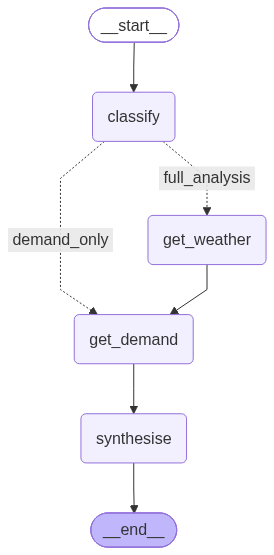

In [31]:
# Draw the workflow graph so the LangGraph control flow is visible.
if LG_AVAILABLE:
    from IPython.display import Image, display
    display(Image(lg_app.get_graph().draw_mermaid_png()))

In [32]:
# Summarise the trade-offs of the three framework options in one table.
FRAMEWORK_TCO = {
    'Python-only': {
        'loc_simple':        30,
        'loc_multi_agent':  400,
        'ext_dependencies':   1,
        'debugging':        'Low (standard Python stack)',
        'multi_agent':      'Manual scaffolding required',
        'observability':    'Manual (print / logging)',
        'learning_curve_d':   0,
        'version_risk':     'None (no framework dependency)',
        'best_for':         'Prototypes, single-step cost-sensitive pipelines',
        'latency_sec':      py_result['latency_sec'],
    },
    'LangChain': {
        'loc_simple':        15,
        'loc_multi_agent':  180,
        'ext_dependencies':   8,
        'debugging':        'Medium-High (abstraction layers)',
        'multi_agent':      'Partial (AgentExecutor)',
        'observability':    'LangSmith (requires account)',
        'learning_curve_d':   3,
        'version_risk':     'High (frequent breaking changes)',
        'best_for':         'RAG pipelines, single-agent tools, rapid prototyping',
        'latency_sec':      round(lc_latency, 2) if lc_latency else 'N/A',
    },
    'LangGraph': {
        'loc_simple':        50,
        'loc_multi_agent':  130,
        'ext_dependencies':   5,
        'debugging':        'Medium (explicit state, step-by-step)',
        'multi_agent':      'First-class (graph-native StateGraph)',
        'observability':    'LangSmith + checkpointing',
        'learning_curve_d':   5,
        'version_risk':     'Medium (stable since v0.2)',
        'best_for':         'Multi-agent systems, human-in-the-loop, complex workflows',
        'latency_sec':      round(lg_latency, 2) if lg_latency else 'N/A',
    },
}

headers = ['Metric'] + list(FRAMEWORK_TCO.keys())
print(f'{headers[0]:<38} {headers[1]:>16} {headers[2]:>16} {headers[3]:>16}')
print('-' * 88)

metrics = [
    'loc_simple', 'loc_multi_agent', 'ext_dependencies',
    'debugging', 'multi_agent', 'learning_curve_d', 'version_risk', 'latency_sec',
]
for m in metrics:
    vals = [str(FRAMEWORK_TCO[fw][m]) for fw in FRAMEWORK_TCO]
    print(f'{m:<38} {vals[0]:>16} {vals[1]:>16} {vals[2]:>16}')

print()
for fw, data in FRAMEWORK_TCO.items():
    print(f'{fw}: {data["best_for"]}')

Metric                                      Python-only        LangChain        LangGraph
----------------------------------------------------------------------------------------
loc_simple                                           30               15               50
loc_multi_agent                                     400              180              130
ext_dependencies                                      1                8                5
debugging                              Low (standard Python stack) Medium-High (abstraction layers) Medium (explicit state, step-by-step)
multi_agent                            Manual scaffolding required Partial (AgentExecutor) First-class (graph-native StateGraph)
learning_curve_d                                      0                3                5
version_risk                           None (no framework dependency) High (frequent breaking changes) Medium (stable since v0.2)
latency_sec                                         6.1         

## Build vs Buy Rubric

Build vs Buy is the decision that precedes framework selection.
If the answer is Buy, you are evaluating vendors, not frameworks.

The rubric scores five axes (each 1-3):
- **Differentiation:** Does this component create competitive advantage?
- **Complexity:** How hard is it to build and maintain at scale?
- **Vendor risk:** How much lock-in does buying create?
- **Speed to value:** How fast does buy vs build deliver the first working version?
- **Cost advantage:** Is build cost (engineering time) lower or higher than buy cost (licensing + integration)?

Score >= 11 = **Build** | Score <= 8 = **Buy** | 9-10 = **Buy + Customize**

In [33]:
# Score each platform decision with the same simple rubric.
# This makes the Build vs Buy choice more explicit and repeatable.
def build_or_buy(component: str, scores: dict) -> dict:
    # scores: each axis is 1=Buy-favoured, 2=Neutral, 3=Build-favoured
    total = sum(scores.values())
    if total >= 11:
        decision  = 'BUILD'
        rationale = 'Component creates differentiation or vendor risk is too high to accept'
    elif total <= 8:
        decision  = 'BUY'
        rationale = 'Commodity capability; vendor delivers faster and cheaper'
    else:
        decision  = 'BUY + CUSTOMIZE'
        rationale = 'Start with vendor solution, extend where differentiation matters'
    return {
        'component': component, 'scores': scores,
        'total': total, 'decision': decision, 'rationale': rationale,
    }

components = [
    ('Orchestration framework (LangGraph)', {
        'differentiation': 1, 'complexity': 2,
        'vendor_risk': 2,     'speed_advantage': 3, 'cost_advantage': 1,
    }),
    ('RAG vector store (Chroma vs Pinecone)', {
        'differentiation': 1, 'complexity': 3,
        'vendor_risk': 1,     'speed_advantage': 1, 'cost_advantage': 2,
    }),
    ('Walmart domain knowledge base (Q&A dataset)', {
        'differentiation': 3, 'complexity': 1,
        'vendor_risk': 3,     'speed_advantage': 1, 'cost_advantage': 3,
    }),
    ('LLM inference (OpenAI API vs self-hosted)', {
        'differentiation': 1, 'complexity': 3,
        'vendor_risk': 2,     'speed_advantage': 1, 'cost_advantage': 1,
    }),
    ('MCP tool server (FastMCP vs custom HTTP)', {
        'differentiation': 1, 'complexity': 2,
        'vendor_risk': 1,     'speed_advantage': 3, 'cost_advantage': 2,
    }),
]

results = [build_or_buy(name, scores) for name, scores in components]

print(f'{"Component":<48} {"Score":>6} {"Decision":>18}')
print('-' * 74)
for r in results:
    print(f'{r["component"]:<48} {r["total"]:>6} {r["decision"]:>18}')

print()
for r in results:
    print(f'{r["component"]}:')
    print(f'  {r["decision"]}: {r["rationale"]}')

Component                                         Score           Decision
--------------------------------------------------------------------------
Orchestration framework (LangGraph)                   9    BUY + CUSTOMIZE
RAG vector store (Chroma vs Pinecone)                 8                BUY
Walmart domain knowledge base (Q&A dataset)          11              BUILD
LLM inference (OpenAI API vs self-hosted)             8                BUY
MCP tool server (FastMCP vs custom HTTP)              9    BUY + CUSTOMIZE

Orchestration framework (LangGraph):
  BUY + CUSTOMIZE: Start with vendor solution, extend where differentiation matters
RAG vector store (Chroma vs Pinecone):
  BUY: Commodity capability; vendor delivers faster and cheaper
Walmart domain knowledge base (Q&A dataset):
  BUILD: Component creates differentiation or vendor risk is too high to accept
LLM inference (OpenAI API vs self-hosted):
  BUY: Commodity capability; vendor delivers faster and cheaper
MCP tool server (F

In [34]:
# Pull the earlier findings into one recommended production stack for Walmart.
WALMART_RETAIL_ASSISTANT_STACK = {
    'use_case':    'Walmart India Retail Assistant',
    'description': 'AI agent for store associates: inventory, policies, demand planning, supplier queries',
    'scale':       '50,000+ queries/day across 4,700 stores',
    'slo':         'P95 latency < 3s, availability 99.5%, error rate < 1%',
    'protocol': {
        'choice':    'MCP (FastMCP)',
        'rationale': (
            'Standardised tool schema enables reuse across store ops, supply chain, and HR agents '
            'without rewriting tool descriptions. MCP server versioning handles quarterly policy '
            'updates with zero changes to agent code. Demonstrated live in this notebook.'
        ),
    },
    'framework': {
        'choice':    'LangGraph',
        'rationale': (
            'Multi-step workflows (classify -> weather -> demand -> synthesise -> escalate) require '
            'explicit typed state management. LangGraph checkpointing supports human-in-the-loop '
            'for supplier reorder approvals. Demonstrated live with real data in this notebook.'
        ),
    },
    'build_buy': {
        'orchestration':   'Build with LangGraph (open-source, score 9 -- BUY+CUSTOMIZE)',
        'mcp_server':      'Build with FastMCP (score 9 -- BUY+CUSTOMIZE, open-source)',
        'vector_store':    'Buy Pinecone (scale + managed SLA, score 8 -- BUY)',
        'knowledge_base':  'Build internally (Walmart IP, cannot outsource, score 11 -- BUILD)',
        'llm_inference':   'Buy OpenAI API for initial scale; re-evaluate at 100k+ daily queries',
    },
    'evaluation_gate': 'Task Success Rate >= 0.80 on 100-case Walmart golden dataset before production',
}

print('Walmart Retail Assistant -- Recommended Production Stack')
print('=' * 58)
for section, content in WALMART_RETAIL_ASSISTANT_STACK.items():
    if isinstance(content, dict):
        print(f'\n{section.upper()}:')
        for k, v in content.items():
            print(f'  {k}: {v}')
    else:
        print(f'{section}: {content}')

Walmart Retail Assistant -- Recommended Production Stack
use_case: Walmart India Retail Assistant
description: AI agent for store associates: inventory, policies, demand planning, supplier queries
scale: 50,000+ queries/day across 4,700 stores
slo: P95 latency < 3s, availability 99.5%, error rate < 1%

PROTOCOL:
  choice: MCP (FastMCP)
  rationale: Standardised tool schema enables reuse across store ops, supply chain, and HR agents without rewriting tool descriptions. MCP server versioning handles quarterly policy updates with zero changes to agent code. Demonstrated live in this notebook.

FRAMEWORK:
  choice: LangGraph
  rationale: Multi-step workflows (classify -> weather -> demand -> synthesise -> escalate) require explicit typed state management. LangGraph checkpointing supports human-in-the-loop for supplier reorder approvals. Demonstrated live with real data in this notebook.

BUILD_BUY:
  orchestration: Build with LangGraph (open-source, score 9 -- BUY+CUSTOMIZE)
  mcp_server: 

In [35]:
# Write the final decision memo to a text file so it can be shared outside the notebook.
lines = [
    'FRAMEWORK SELECTION MATRIX',
    'Advanced Agentic AI -- Production Engineering | India Track',
    'Module 1 -- Engineering Decisions for AI Systems',
    '=' * 62,
    '',
    'USE CASE: Walmart India Retail Assistant',
    '50,000+ queries/day | 4,700 stores | P95 < 3s SLO',
    '',
    'LIVE DATA VERIFIED DURING THIS SESSION',
    f'  OpenWeatherMap -- {STORE_CITY}: {live_weather["temperature_c"]} C, '
    f'{live_weather["condition"]}, humidity {live_weather["humidity_pct"]}%',
    f'  Tavily Search  -- {len(live_demand["results"])} market articles retrieved for {STORE_CITY}',
    '',
    'PROTOCOL SELECTION',
    '  Choice : MCP (FastMCP)',
    f'  REST latency observed  : {rest_result["latency_sec"]}s | Cost: ${rest_result["cost_usd"]}',
    f'  MCP latency observed   : {mcp_result["latency_sec"]}s | Cost: ${mcp_result["cost_usd"]}',
    '  Decision factor: Schema standardisation for multi-agent reuse across 4,700 stores',
    '',
    'FRAMEWORK SELECTION',
    '  Choice   : LangGraph',
    '  Rejected : LangChain (insufficient stateful multi-agent control)',
    '  Rejected : Python-only (too much custom scaffolding at 50k+ queries/day)',
    '  Decision factor: Typed StateGraph + human-in-the-loop checkpointing',
    '',
    'BUILD vs BUY DECISIONS',
]

for r in results:
    lines.append(f'  {r["component"]}')
    lines.append(f'    Decision : {r["decision"]} (score: {r["total"]}/15)')
    lines.append(f'    Rationale: {r["rationale"]}')

lines += [
    '',
    'RECOMMENDED PRODUCTION STACK',
    '  Protocol        : MCP (FastMCP server, open-source)',
    '  Orchestration   : LangGraph (StateGraph, typed state, checkpointing)',
    '  Vector store    : Pinecone (managed, buy)',
    '  Knowledge base  : Walmart internal Q&A dataset (build)',
    '  LLM inference   : OpenAI API gpt-4o-mini (buy, re-evaluate at 100k+ daily queries)',
    '  Evaluation gate : Task Success Rate >= 0.80 on 100-case Walmart golden dataset',
    '',
    'TOOL INTEGRATIONS DEMONSTRATED LIVE IN THIS SESSION',
    '  OpenWeatherMap : REST and MCP -- real weather data every invocation',
    '  Tavily Search  : REST and MCP -- real market demand signals every invocation',
    '  FastMCP        : Real MCP server with auto-discovered tool schemas and live tool execution',
]

report = '\n'.join(lines)
with open('framework_selection_matrix.txt', 'w') as f:
    f.write(report)

print(report)
print()
print('Saved: framework_selection_matrix.txt')

FRAMEWORK SELECTION MATRIX
Advanced Agentic AI -- Production Engineering | India Track
Module 1 -- Engineering Decisions for AI Systems

USE CASE: Walmart India Retail Assistant
50,000+ queries/day | 4,700 stores | P95 < 3s SLO

LIVE DATA VERIFIED DURING THIS SESSION
  OpenWeatherMap -- Bengaluru: 23.8 C, overcast clouds, humidity 77%
  Tavily Search  -- 3 market articles retrieved for Bengaluru

PROTOCOL SELECTION
  Choice : MCP (FastMCP)
  REST latency observed  : 10.35s | Cost: $0.000443
  MCP latency observed   : 18.72s | Cost: $0.001063
  Decision factor: Schema standardisation for multi-agent reuse across 4,700 stores

FRAMEWORK SELECTION
  Choice   : LangGraph
  Rejected : LangChain (insufficient stateful multi-agent control)
  Rejected : Python-only (too much custom scaffolding at 50k+ queries/day)
  Decision factor: Typed StateGraph + human-in-the-loop checkpointing

BUILD vs BUY DECISIONS
  Orchestration framework (LangGraph)
    Decision : BUY + CUSTOMIZE (score: 9/15)
    R

## Summary

You have built and compared production-grade AI protocol and framework implementations using **live external data**:

- **Protocol:** REST vs MCP -- both called real OpenWeatherMap and Tavily APIs. MCP wins for multi-agent reuse at Walmart scale because tool schemas live on the server, not in every agent's code.
- **Framework:** All three frameworks fetched real weather and real demand signals and produced grounded recommendations from live data. LangGraph's explicit typed state is the right choice for the Walmart Retail Assistant's multi-step workflow.
- **Build vs Buy:** Quantified per component. Domain knowledge base is always BUILD. Everything else is BUY or BUY+CUSTOMIZE using open-source tools.

**Key principle:** These decisions compound. Wrong protocol forces a framework rewrite. Wrong Build vs Buy wastes 3-6 months of engineering. Score the rubric before writing a single line of production code.

**Your deliverable:** `framework_selection_matrix.txt` -- ARB-ready with live latency and cost data from this session.

**Next:** IN04 -- Agent Design Principles